# 0.0 Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection
import xgboost as xgb
import catboost as cat

from sklearn import metrics as mt
from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_validate, TunedThresholdClassifierCV
from sklearn            import ensemble             as en
from sklearn            import linear_model         as lm

d:\Comunidade DS\Portifólio de Projetos\repos\ds_fraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.1 Helper Functions

In [2]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

## 0.2 Loading Data

In [3]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [4]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
5054281,354,CASH_IN,112939.84,C1355890557,99681.68,212621.52,C1151085491,236512.75,123572.91,0,0


# 1.0 Descrição dos dados

In [5]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [6]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [9]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [10]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [12]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [13]:
cat_attributes.sample(5)

,type,name_orig,name_dest
1120205,CASH_OUT,C746318640,C1215409003
5324147,CASH_OUT,C1294214085,C1733866787
2514561,CASH_OUT,C293170546,C1341009103
1312739,CASH_IN,C1344043575,C665366766
523620,CASH_IN,C740432846,C34078006


### 1.5.1 Numerical Attributes

In [14]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

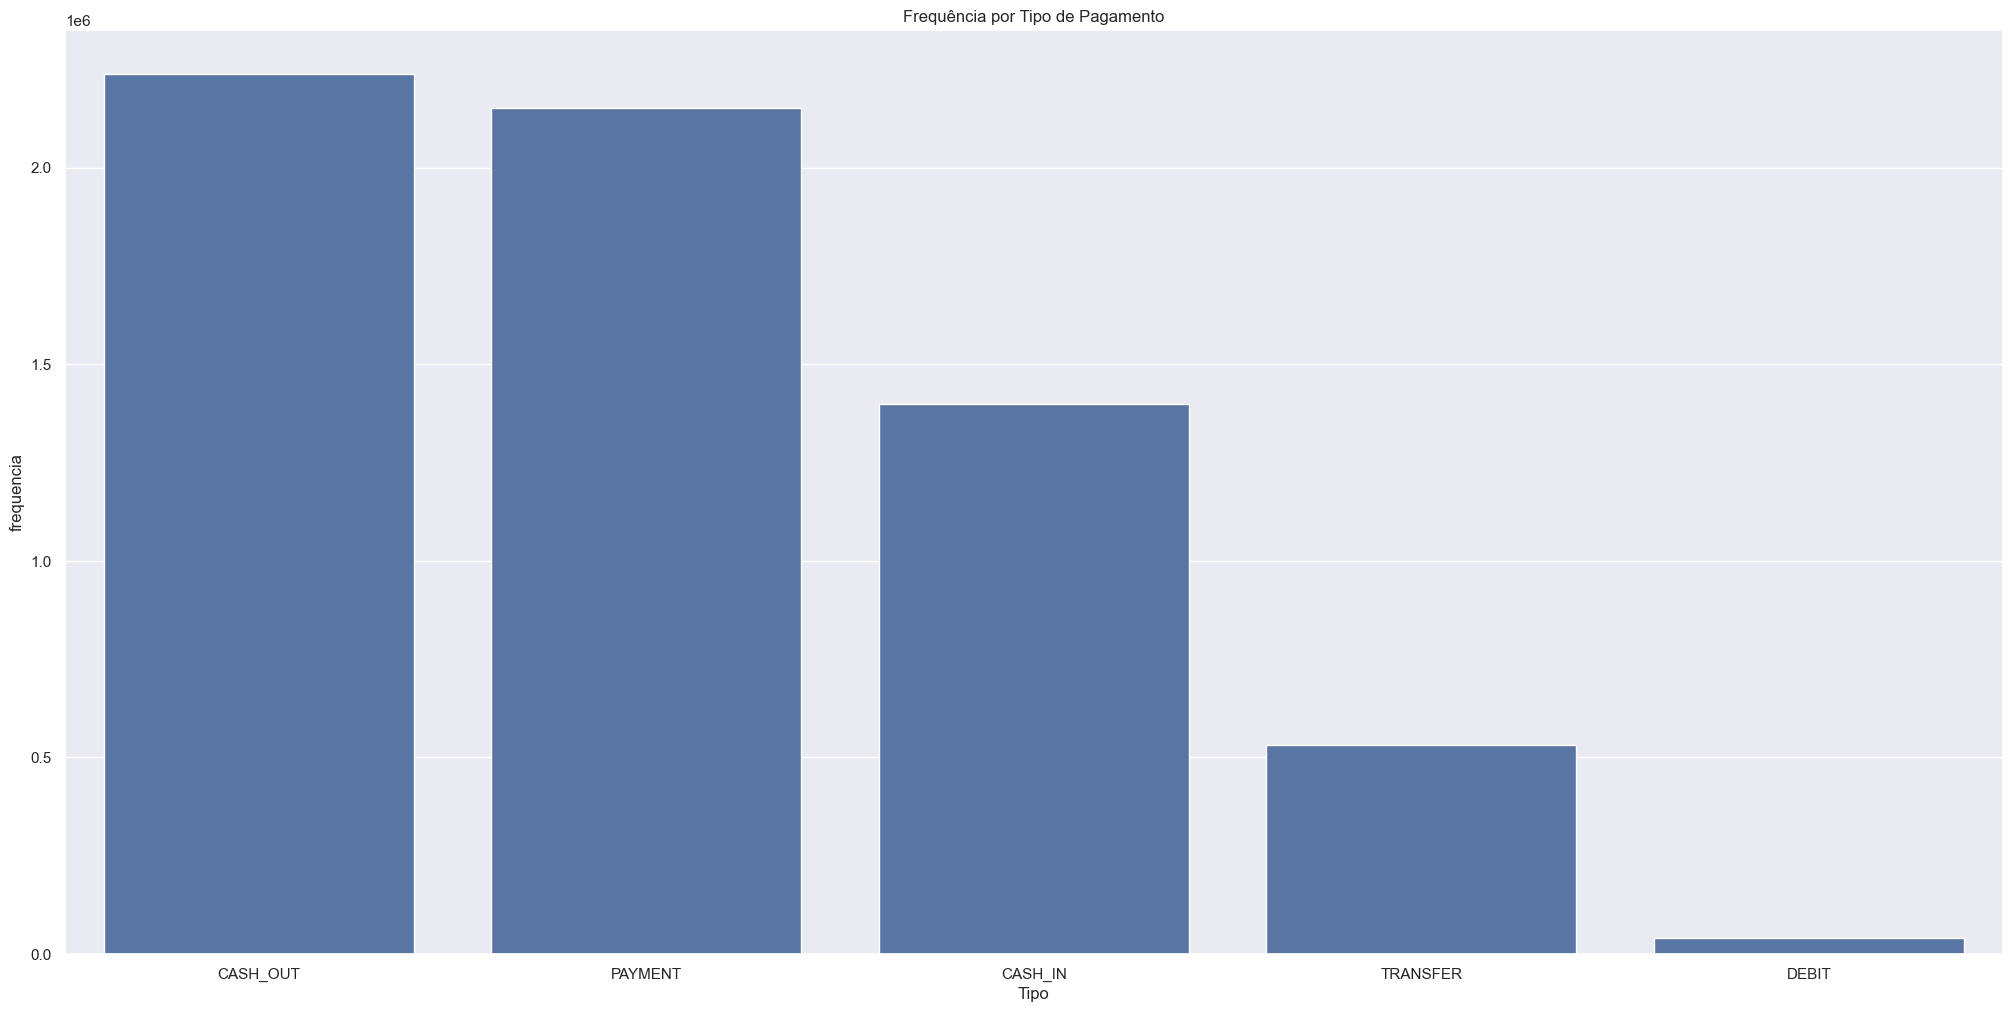

In [15]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

# 2.0 Feature Engineering

In [16]:
df2 = df1.copy()

In [17]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [18]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)

In [19]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [20]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


# 3.0 Filtragem de Variáveis

In [21]:
df3 = df2.copy()

In [22]:
df3.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2359406,190,PAYMENT,5343.69,C884022734,182.0,0.00,M1345368302,0.00,0.0,0,0,8,22,Evening
6304394,684,PAYMENT,25631.24,C574152329,206158.0,180526.76,M367851647,0.00,0.0,0,0,29,12,Afternoon
4624221,329,PAYMENT,13997.07,C1451294052,0.0,0.00,M621153763,0.00,0.0,0,0,14,17,Afternoon
5131283,356,CASH_IN,34576.67,C5480672,6007.0,40583.67,C1423520604,0.00,0.0,0,0,15,20,Evening
5350853,375,CASH_OUT,131977.30,C1112847974,10956.0,0.00,C2064717174,654635.11,786612.4,0,0,16,15,Afternoon


In [23]:
# Não existe nenhum cliente de origem do tipo Merchant
df_aux2 = df3[df3['name_dest'].str.contains(r'^M', na=False)]

In [24]:
# Não existe nenhuma transição de Merchant classificada como fraude
df_aux2[df_aux2['is_fraud'] == 1].shape

(0, 14)

In [25]:
df_aux = df3[df3['amount'] > 9000000]

In [26]:
df_aux.shape

(6335, 14)

In [27]:
df3_filtered = df3[(~df3['name_dest'].str.contains(r'^M', na=False)) & (df3['amount'] <= 8999999) ]

In [28]:
df3_filtered.shape

(4204790, 14)

In [29]:
num_attributes = df3_filtered.select_dtypes( include=['int64', 'float64'])
cat_attributes = df3_filtered.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

# 4.0 Análise Exploratória de Dados

In [30]:
df4 = df3_filtered.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

In [31]:
df_valid = df4[df4['is_fraud'] == 0]
df_fraud = df4[df4['is_fraud'] == 1]
df_flagged_fraud = df4[df4['is_flagged_fraud'] == 1] 


print(f'Quantidade de transações válidas: {df_valid.shape[0]}')
print(f'Quantidade de transações fraudulentas: {df_fraud.shape[0]}')
print(f'Quantidade de transações com flag de fraudulentas: {df_flagged_fraud.shape[0]}')

Quantidade de transações válidas: 4196921
Quantidade de transações fraudulentas: 7869
Quantidade de transações com flag de fraudulentas: 12


In [32]:
df_fraud['amount'].max()

np.float64(8994286.69)

In [33]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
1059619,109,CASH_OUT,126375.17,C1736726302,126375.17,0.0,C1409221160,0.00,126375.17,1,0,5,13,Afternoon
1935463,177,CASH_OUT,158000.29,C927253405,158000.29,0.0,C1087985389,2330671.17,2488671.46,1,0,8,9,Morning
3208445,249,CASH_OUT,299298.50,C529456580,299298.50,0.0,C1686770786,30615.00,329913.50,1,0,11,9,Morning
6054552,495,CASH_OUT,797710.80,C853913532,797710.80,0.0,C721674315,49988.57,847699.37,1,0,21,15,Afternoon
6118266,533,TRANSFER,18042.11,C977625973,18042.11,0.0,C1844577837,0.00,0.00,1,0,23,5,Morning
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,1,1,Night
5188036,366,TRANSFER,1846748.79,C1895315229,1846748.79,0.0,C1691229227,0.00,0.00,1,0,16,6,Morning
1030635,80,TRANSFER,42659.39,C1702857614,42659.39,0.0,C952860391,0.00,0.00,1,0,4,8,Morning
1023030,47,CASH_OUT,1388951.50,C1476504573,1388951.50,0.0,C598780092,459273.45,1848224.95,1,0,2,23,Evening
6296660,676,TRANSFER,327773.15,C505663484,327773.15,0.0,C667256614,0.00,0.00,1,0,29,4,Night


In [34]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1,9,20,Evening
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1,28,23,Evening
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1,17,3,Night
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.0,0.0,1,1,31,21,Evening
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1,25,10,Morning
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1,12,15,Afternoon
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1,11,10,Morning
6351225,702,TRANSFER,3171085.59,C1892216157,3171085.59,3171085.59,C1308068787,0.0,0.0,1,1,30,6,Morning
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1,26,17,Afternoon
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1,27,22,Evening


In [35]:
df_test = df4[df4['amount'] >= 200000]

In [36]:
df_test.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
405556,18,CASH_IN,215026.49,C878316430,22772.00,237798.49,C609151650,0.00,0.00,0,0,1,18,Evening
3181244,239,CASH_IN,312092.68,C2123764657,16948515.88,17260608.56,C485460615,1155518.62,843425.94,0,0,10,23,Evening
1154063,131,CASH_IN,387234.24,C86322602,551.00,387785.24,C525293289,1030657.17,643422.93,0,0,6,11,Morning
6014312,449,CASH_OUT,426837.65,C289612537,166804.45,0.00,C130798766,493573.17,920410.83,0,0,19,17,Afternoon
2624075,208,CASH_OUT,218643.54,C235837759,10213.00,0.00,C774017137,972332.00,1190975.55,0,0,9,16,Afternoon


### 4.1.2 Numerical Attributes

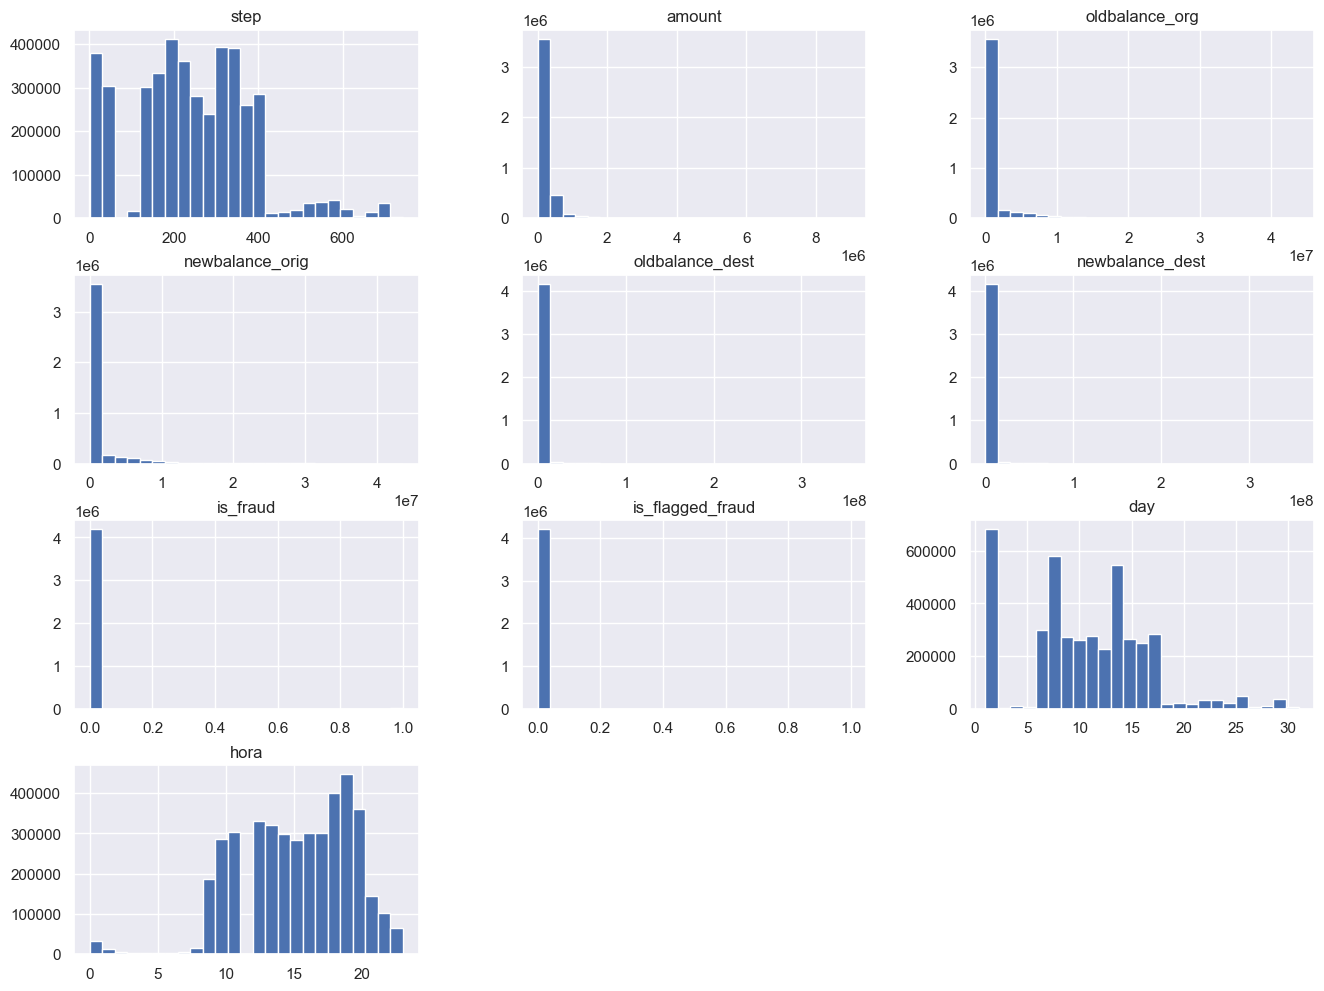

In [37]:
num_attributes.hist(bins= 25, figsize=(16,12));

### 4.1.2 Categorical Variables

<Axes: xlabel='count', ylabel='type'>

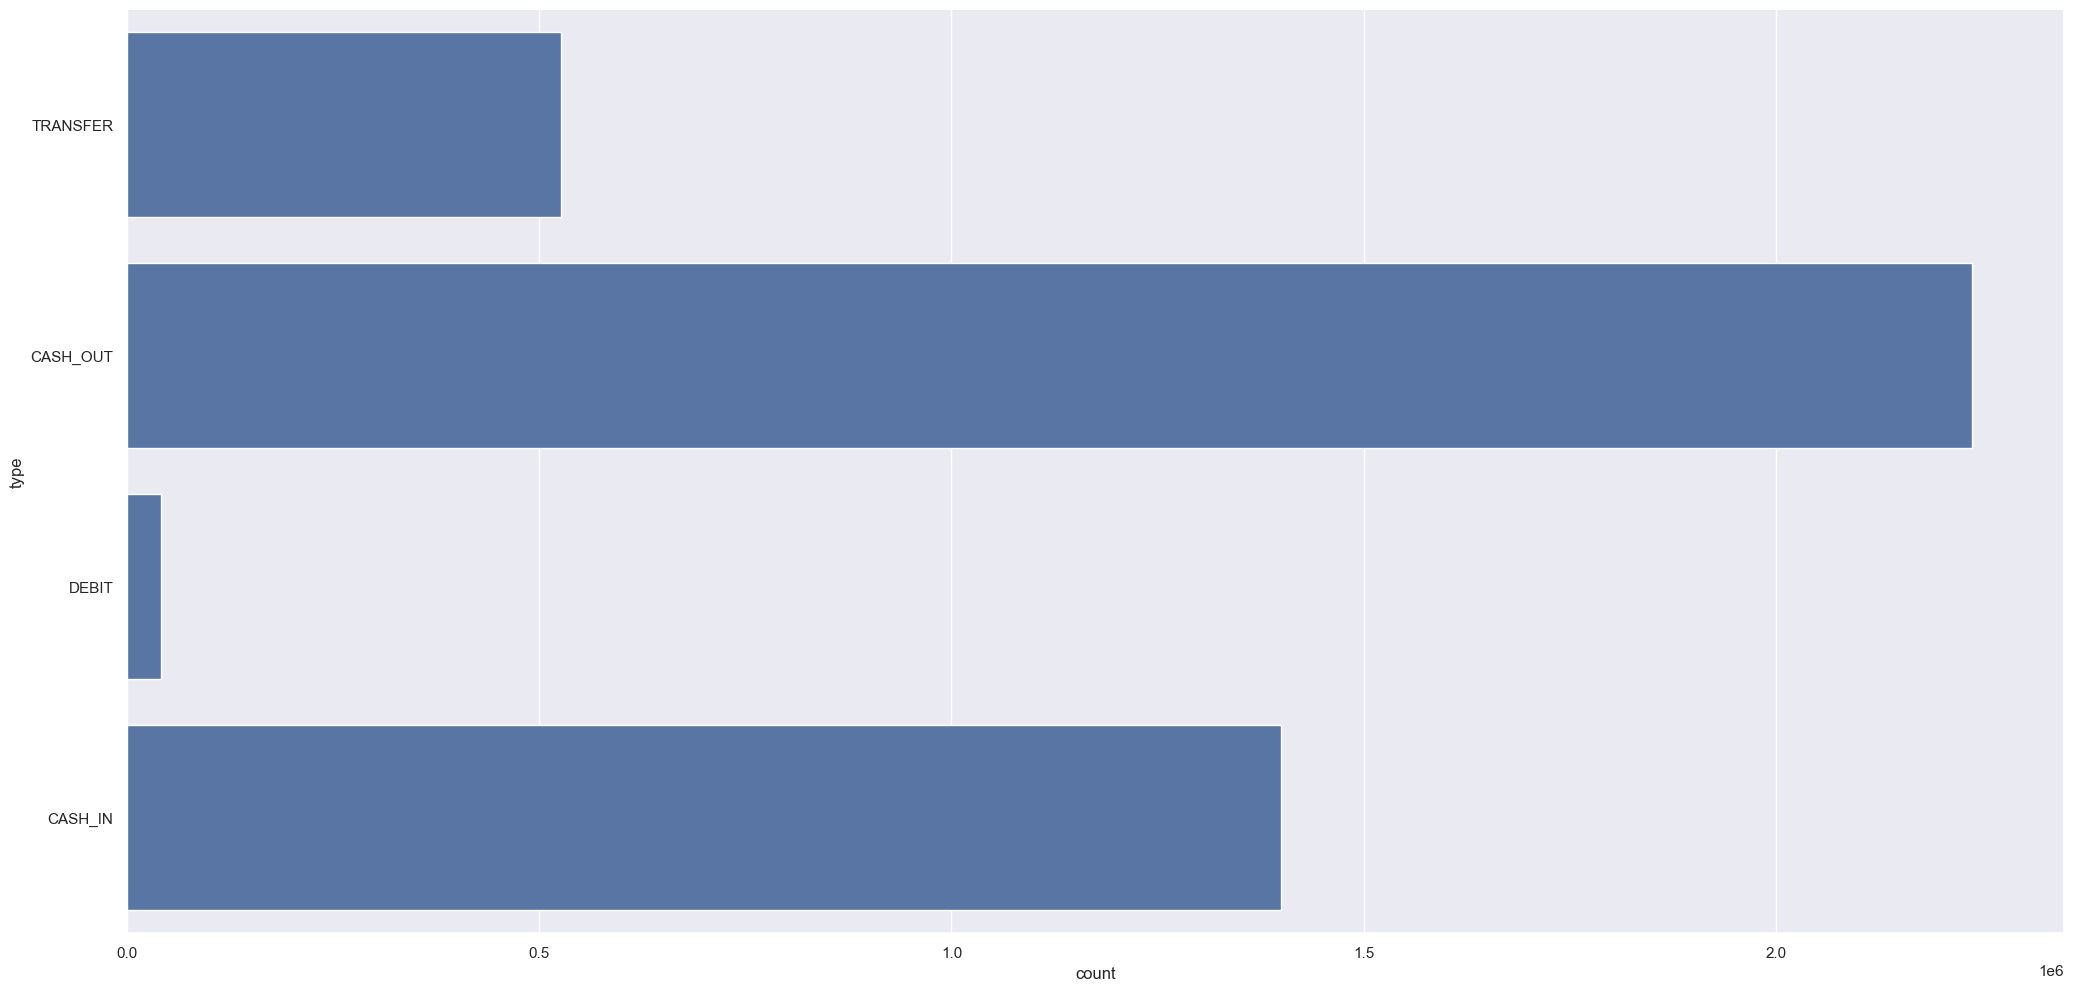

In [38]:
sns.countplot (df4['type'])

## 4.2 Analise Bivariada

In [39]:
df4.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud', 'day', 'hora', 'period_of_day'],
      dtype='object')

<Axes: xlabel='type', ylabel='is_fraud'>

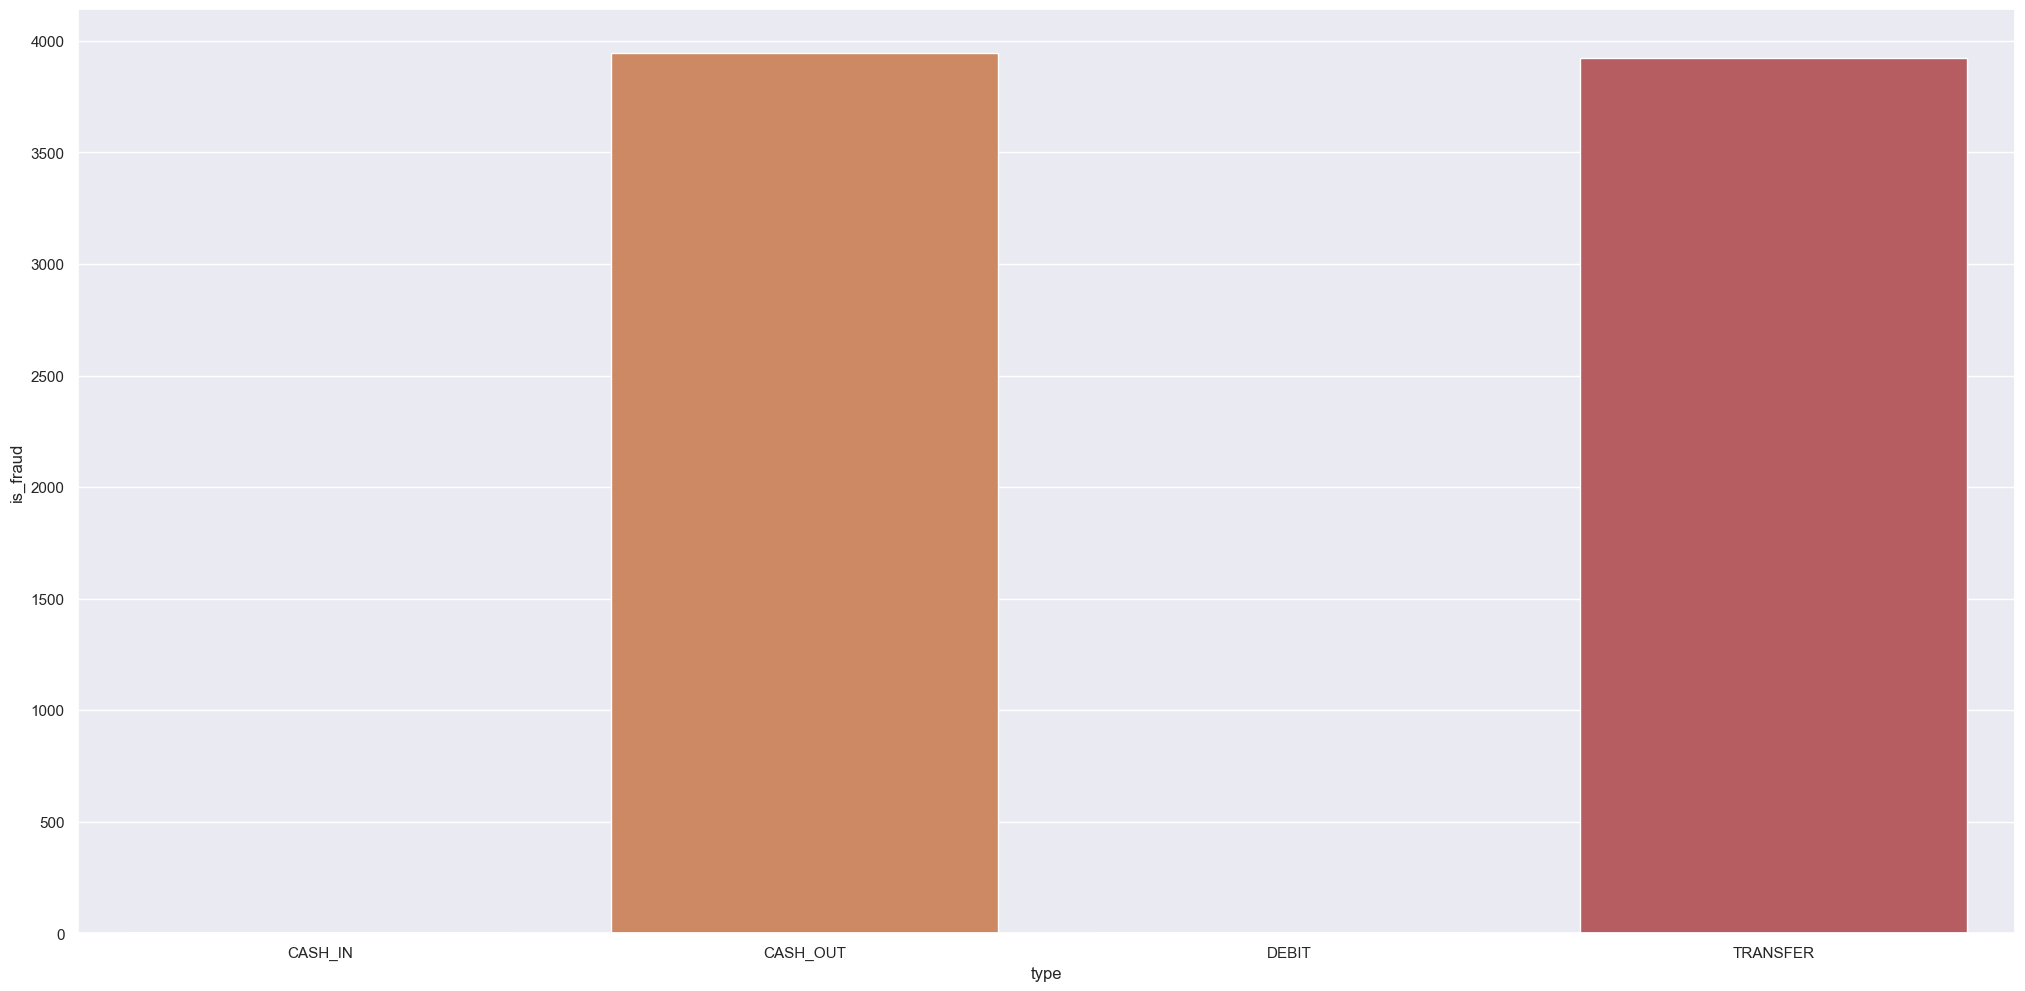

In [40]:
# Tipos de Transações que mais são fraudes

aux1 = df4[['type', 'is_fraud']].groupby('type').sum().reset_index()

sns.barplot( x='type', y='is_fraud', data=aux1, hue='type')

<Axes: xlabel='period_of_day', ylabel='is_fraud'>

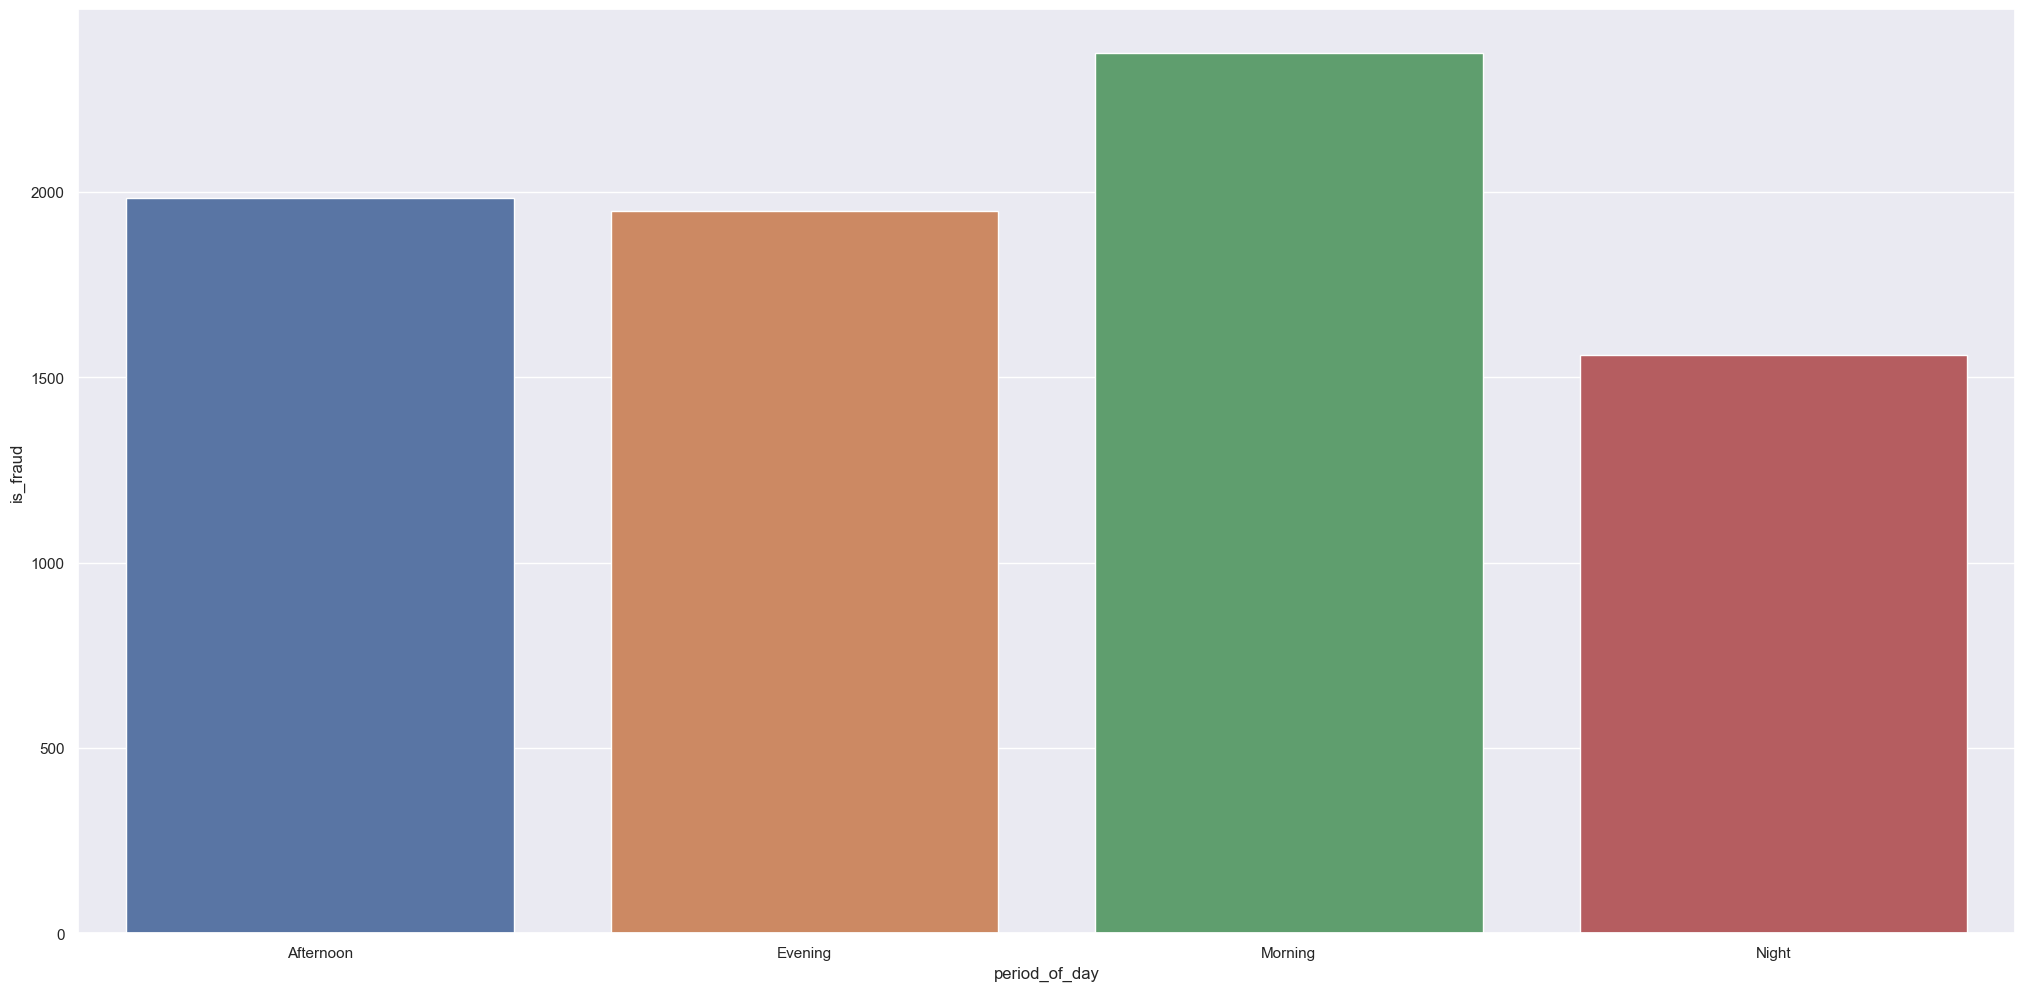

In [41]:
# Periodo do dia que mais ocorrem fraudes

aux1 = df4[['period_of_day', 'is_fraud']].groupby('period_of_day').sum().reset_index()

sns.barplot( x='period_of_day', y='is_fraud', data=aux1, hue='period_of_day')

In [42]:
df4.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night
10,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night


In [43]:
# Quantidade de transações fraudulentas no qual o total enviado é igual ao valor total da conta
aux2 = df4[df4['amount'] == df4['oldbalance_org']]

aux2.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,1,1,Night
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,1,1,Night
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,1,1,Night
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,1,1,Night
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,1,1,Night


In [44]:
# Quantidade de transações válidas: 4196921
# Quantidade de transações fraudulentas: 7869
# Quantidade de transações com flag de fraudulentas: 12

In [45]:
aux2.shape

(7836, 14)

In [46]:
# As transações que são fraudes, geralmente são aquelas transações que "limpam" o valor da conta do cliente.

In [47]:
# Não existe clientes que fizeram mais de uma transação fraudulenta
fraude_por_cliente = df4[df4['is_fraud'] == 1].groupby('name_orig').size().reset_index(name='fraude_total')

In [48]:
df_fraud_aux = df4.merge(fraude_por_cliente, on='name_orig', how='left')

In [49]:
df_fraud_aux['fraude_total'] = df_fraud_aux['fraude_total'].fillna(0)
df_fraud_aux.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,fraude_total
0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night,1.0
1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night,1.0
2,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night,0.0
3,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night,0.0
4,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night,0.0


<Axes: xlabel='fraude_total', ylabel='count'>

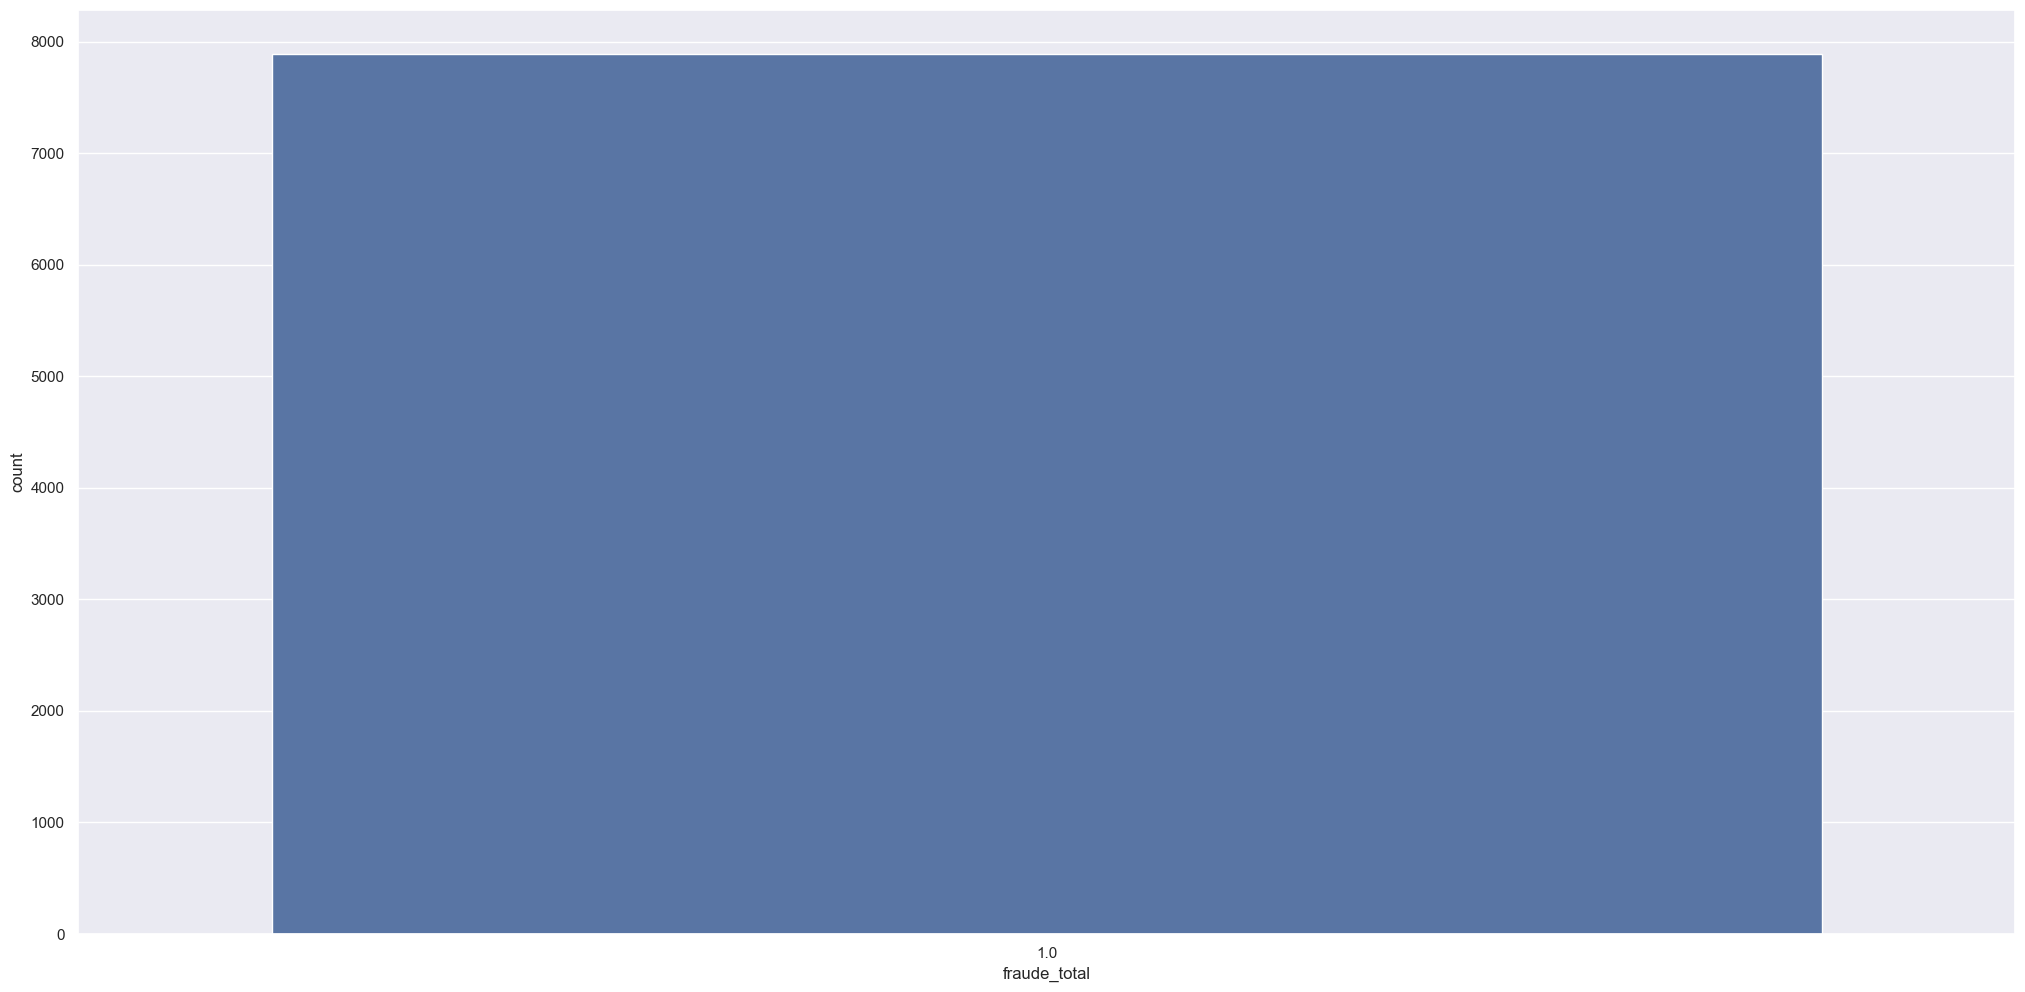

In [50]:

sns.countplot(data=df_fraud_aux[df_fraud_aux['fraude_total'] > 0], x='fraude_total')

## 4.3 Análise Multivariada

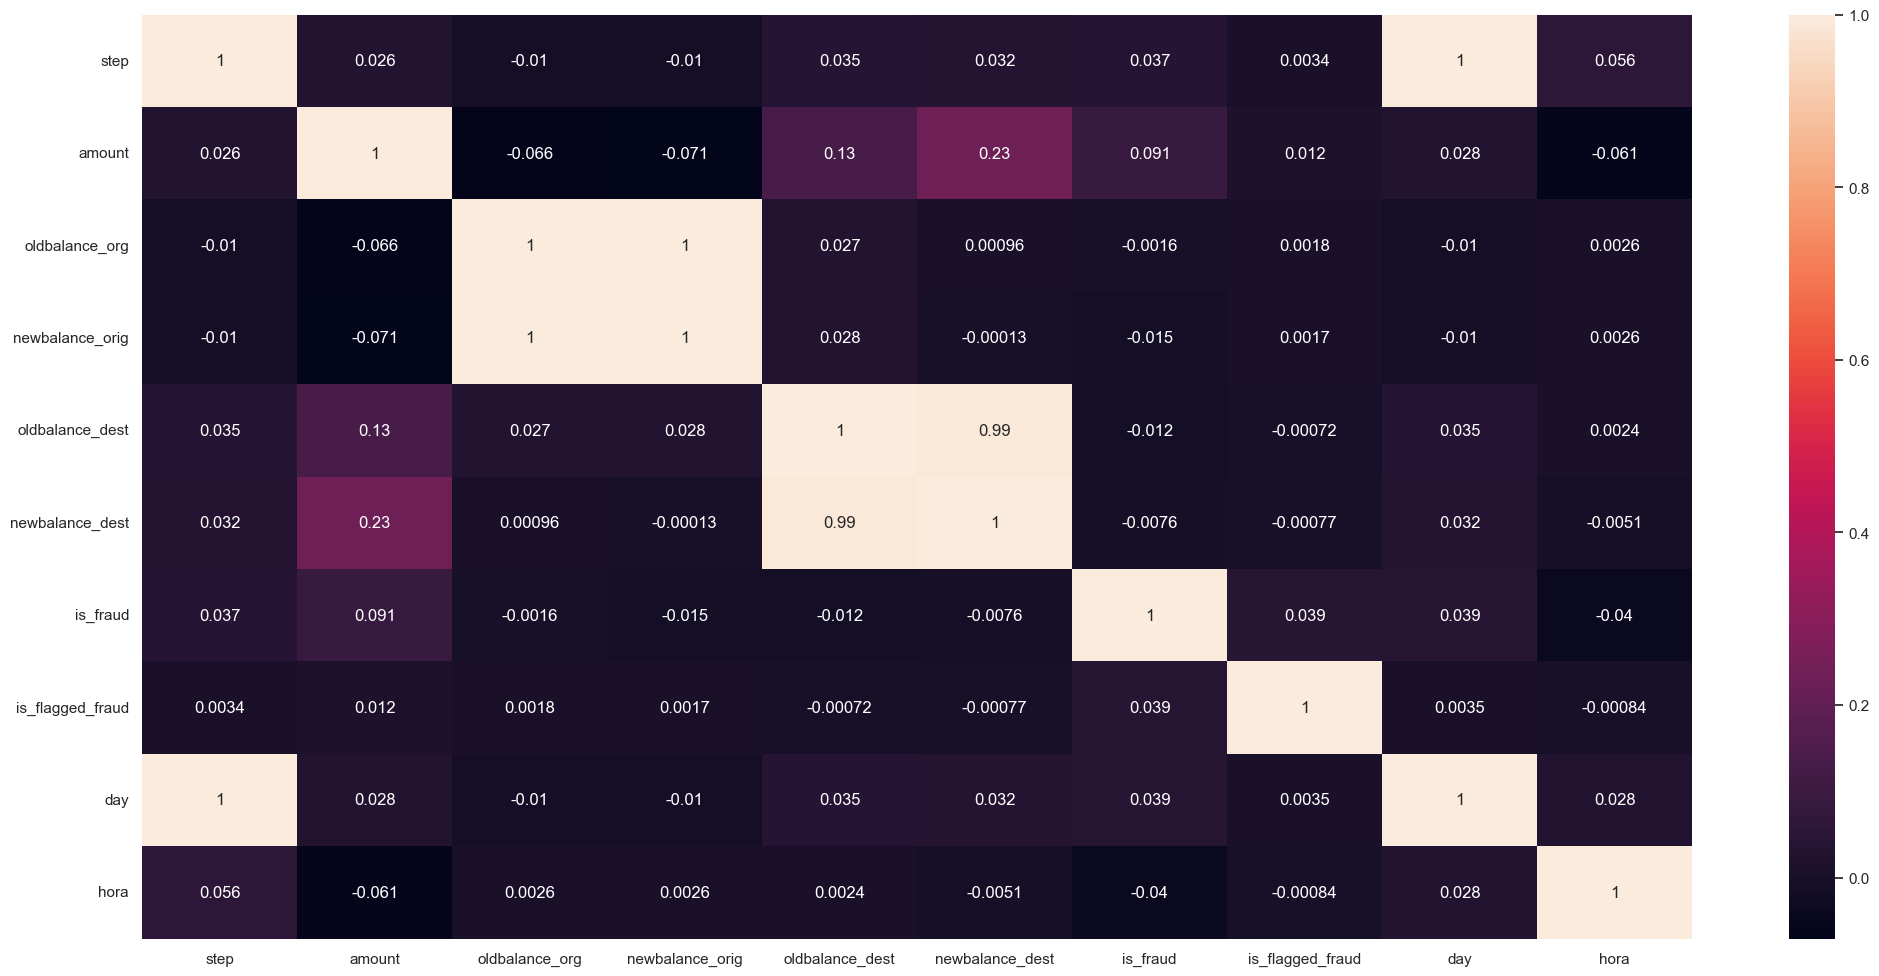

In [51]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);

# 5.0 Data Preparation

In [66]:
df5 = df4.copy()
df5_2 = df4.copy()

## 5.2 Train Test Validation Split

In [86]:
train, test = train_test_split(df5, test_size=0.2, random_state=42, stratify=df5['is_fraud'])
test, val = train_test_split(test, test_size=0.2, random_state=42, stratify=test['is_fraud'])

In [87]:
print("Distribuição original:")
print(df5['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no treino:")
print(train['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no teste:")
print(test['is_fraud'].value_counts(normalize=True))

print("\nDistribuição na validação:")
print(val['is_fraud'].value_counts(normalize=True))

Distribuição original:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no treino:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição na validação:
is_fraud
0    0.998127
1    0.001873
Name: proportion, dtype: float64


## 5.1 Transformation

In [ ]:
# 0 => $0.1
eps = 0.001 

df5['amount'] = np.log(df5.pop('amount')+eps)
df5['oldbalance_org'] = np.log(df5.pop('oldbalance_org')+eps)
df5['newbalance_orig'] = np.log(df5.pop('newbalance_orig')+eps)
df5['oldbalance_dest'] = np.log(df5.pop('oldbalance_dest')+eps)
df5['newbalance_dest'] = np.log(df5.pop('newbalance_dest')+eps)

### 5.1.1 Encoding

In [68]:
df5 = pd.get_dummies(df5, prefix=['type'], columns=['type'])

## 5.2 Train Test Validation Split

Distribuição original:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no treino:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição na validação:
is_fraud
0    0.998127
1    0.001873
Name: proportion, dtype: float64


## 5.1 Transformation

### 5.1.1 One Hot Encoding

In [57]:
df5.head()

,step,name_orig,name_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,amount,oldbalance_org,newbalance_orig,oldbalance_dest,newbalance_dest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_TRANSFER
2,1,C1305486145,C553264065,1,0,1,1,Night,5.198503,5.198503,-6.907755,-6.907755,-6.907755,False,False,False,True
3,1,C840083671,C38997010,1,0,1,1,Night,5.198503,5.198503,-6.907755,9.960907,-6.907755,False,True,False,False
9,1,C712410124,C195600860,0,0,1,1,Night,8.582563,10.638736,10.501836,10.642993,10.605317,False,False,True,False
10,1,C1900366749,C997608398,0,0,1,1,Night,9.174189,8.404025,-6.907755,9.291460,11.970237,False,False,True,False
15,1,C905080434,C476402209,0,0,1,1,Night,12.342062,9.637241,-6.907755,8.533657,10.849598,False,True,False,False


# 6.0 Feature Selection

In [58]:
df6 = train.copy()

In [59]:
df6_val = val.copy()

In [60]:
df6.columns

Index(['step', 'name_orig', 'name_dest', 'is_fraud', 'is_flagged_fraud', 'day',
       'hora', 'period_of_day', 'amount', 'oldbalance_org', 'newbalance_orig',
       'oldbalance_dest', 'newbalance_dest', 'type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_TRANSFER'],
      dtype='object')

In [61]:
cols_drop = ['name_orig', 'name_dest', 'period_of_day', 'hora', 'day']
df6 = df6.drop(cols_drop, axis=1)
df6_val = df6_val.drop(cols_drop, axis=1)


In [62]:
X_train = df6.copy()
y_train = X_train['is_fraud']
X_train  = X_train.drop('is_fraud', axis=1)

X_train_val = df6_val.copy()
y_train_val = X_train_val['is_fraud']
X_train_val  = X_train_val.drop('is_fraud', axis=1)

# 7.0 Machine Learning Modeling

## 7.1 Random Forest Classifier

In [ ]:
#define

rfc = en.RandomForestClassifier(max_depth=15, n_estimators=50)

# train

rfc.fit(X_train, y_train)

# performace 

y_hat_test = rfc.predict(X_train_val)




Acurácia: 0.9994975972364876
Precision: 0.9873015873015873
Recall: 0.7410643367752184
F1-Score: 0.8466424682395645


In [ ]:
acc = mt.accuracy_score(y_train_val, y_hat_test)

precision = mt.precision_score(y_train_val, y_hat_test)

recall = mt.recall_score(y_train_val, y_hat_test)

f1_score = mt.f1_score(y_train_val, y_hat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

In [65]:
mt.balanced_accuracy_score(y_train_val,y_hat_test)

np.float64(0.8705232332744013)

In [66]:
scores = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [67]:
scores

{'fit_time': array([73.1875124 , 74.64873266, 73.44302559, 73.95746636, 65.95286036]),
 'score_time': array([0.42381716, 0.43095613, 0.48618364, 0.42259145, 0.40600848]),
 'test_score': array([0.86902528, 0.86110739, 0.88246267, 0.8769804 , 0.85116442])}

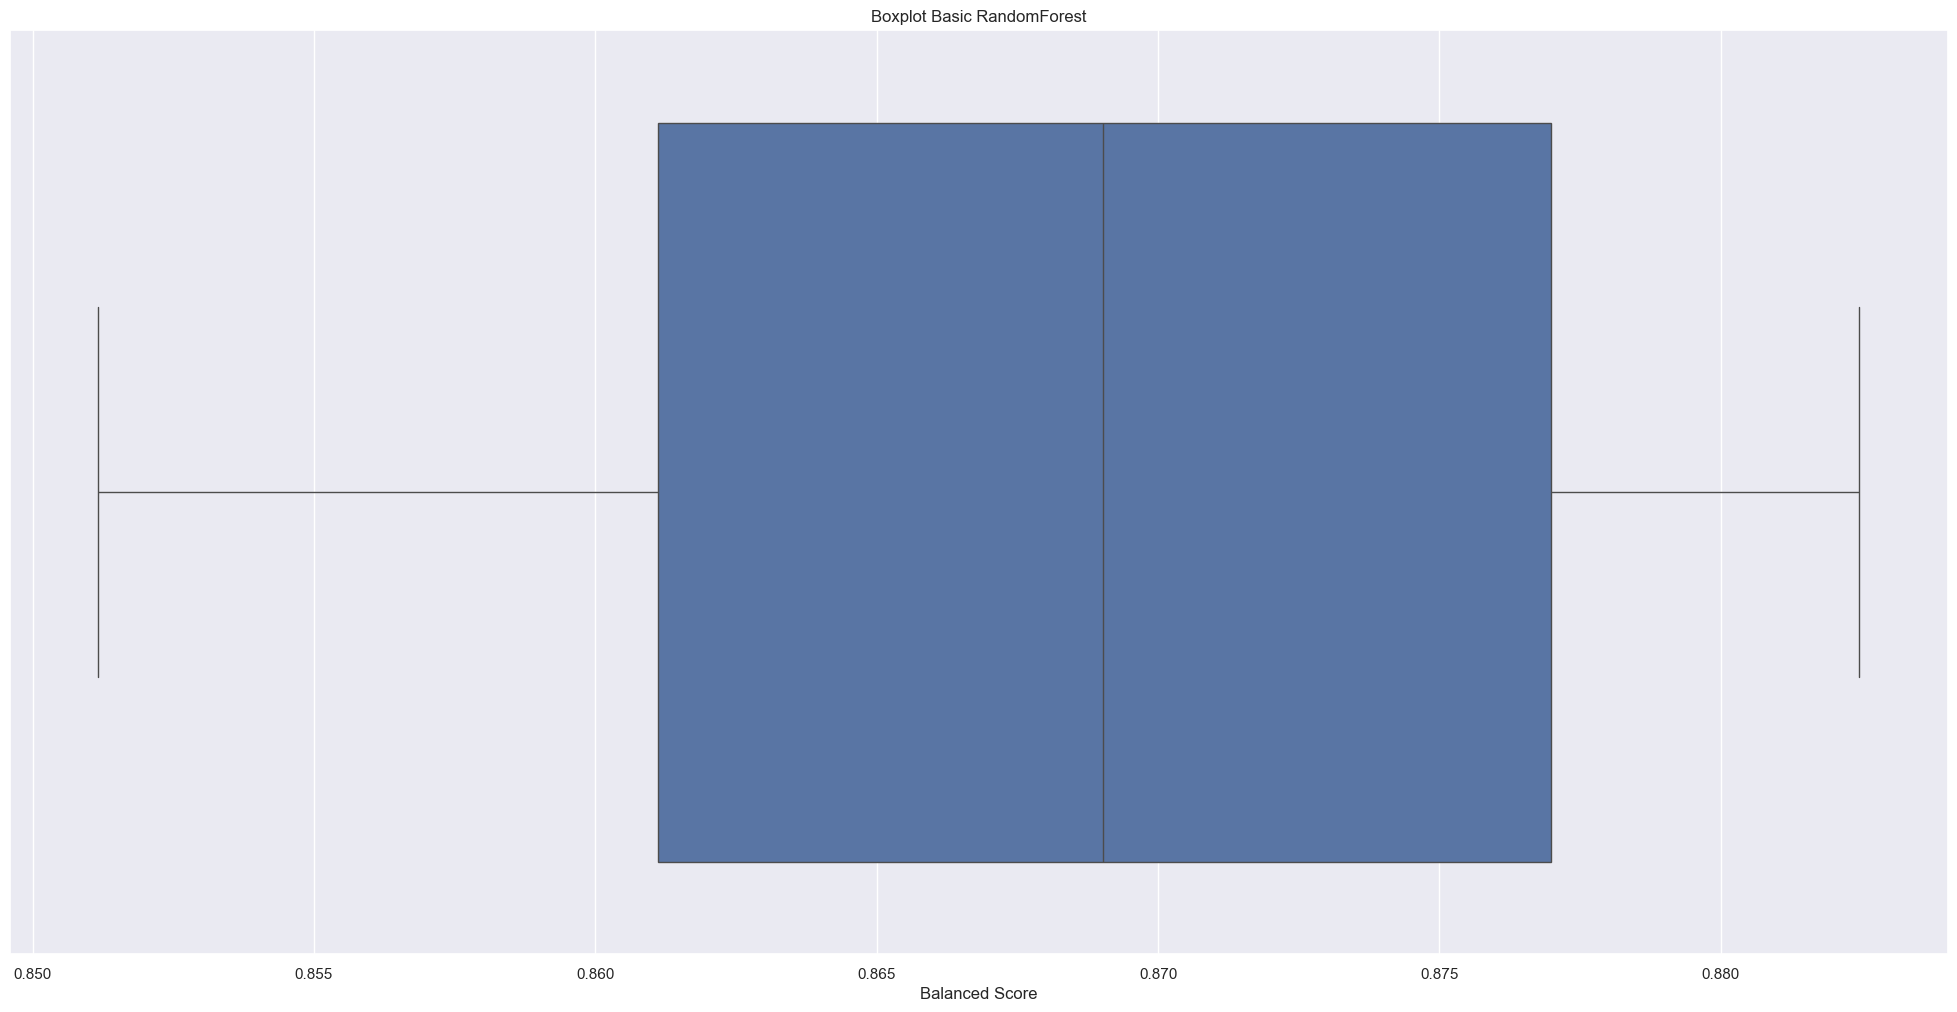

In [68]:
# Cria o boxplot para test_score
sns.boxplot(x=scores['test_score'])
plt.title('Boxplot Basic RandomForest')
plt.xlabel('Balanced Score')
plt.show()

### Random Forest Tunned

In [69]:
rf_tunned = TunedThresholdClassifierCV(rfc, scoring="balanced_accuracy").fit(X_train, y_train)

In [70]:
print(f"Cut-off point found at {rf_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [71]:
yhat_tunned = rfc.predict_proba(X_train_val)

In [72]:
yhat_tunned = yhat_tunned[:,1]
th = 0.010
yhat_tunned_a = [1 if i > th else 0 for i in yhat_tunned]

In [73]:
acc = mt.accuracy_score(y_train_val, yhat_tunned_a)

precision = mt.precision_score(y_train_val, yhat_tunned_a)

recall = mt.recall_score(y_train_val, yhat_tunned_a)

f1_score = mt.f1_score(y_train_val, yhat_tunned_a)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9945984270928866
Precision: 0.24963103520978283
Recall: 0.9404289118347895
F1-Score: 0.39453515494835056


In [74]:
mt.balanced_accuracy_score(y_train_val,yhat_tunned_a)

np.float64(0.9675644502584897)

In [75]:
mt.confusion_matrix(y_train_val,y_hat_test)

array([[671496,     12],
       [   326,    933]])

In [76]:
mt.confusion_matrix(y_train_val,yhat_tunned_a)

array([[667949,   3559],
       [    75,   1184]])

In [77]:
scores_rfc_tunned = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [78]:
# acc = mt.accuracy_score(y_train_val, yhat_test)

# precision = mt.precision_score(y_train_val, yhat_test)

# recall = mt.recall_score(y_train_val, yhat_test)

# f1_score = mt.f1_score(y_train_val, yhat_test)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [79]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [80]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [81]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

## 7.2 Logistic Regression

In [82]:
# definition

lr = lm.LogisticRegression(max_iter=1000)

# training (fit)

lr.fit(X_train, y_train)

# performace

y_hat_test_logistic = lr.predict_proba(X_train_val)

# acc = mt.accuracy_score(y_train_val, y_hat_test_logistic)
# precision = mt.precision_score(y_train_val, y_hat_test_logistic)
# recall = mt.recall_score(y_train_val, y_hat_test_logistic)
# f1_score = mt.f1_score(y_train_val, y_hat_test_logistic)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [83]:
scores_logistic = cross_validate(lr, X_train_val, y_train_val, scoring='balanced_accuracy')

In [84]:
scores_logistic

{'fit_time': array([6.2967999 , 5.46175075, 7.72456741, 6.28516293, 5.38498259]),
 'score_time': array([0.01325345, 0.00525069, 0.02326393, 0.0213635 , 0.02323508]),
 'test_score': array([0.79560886, 0.76186753, 0.78881111, 0.77973584, 0.75988341])}

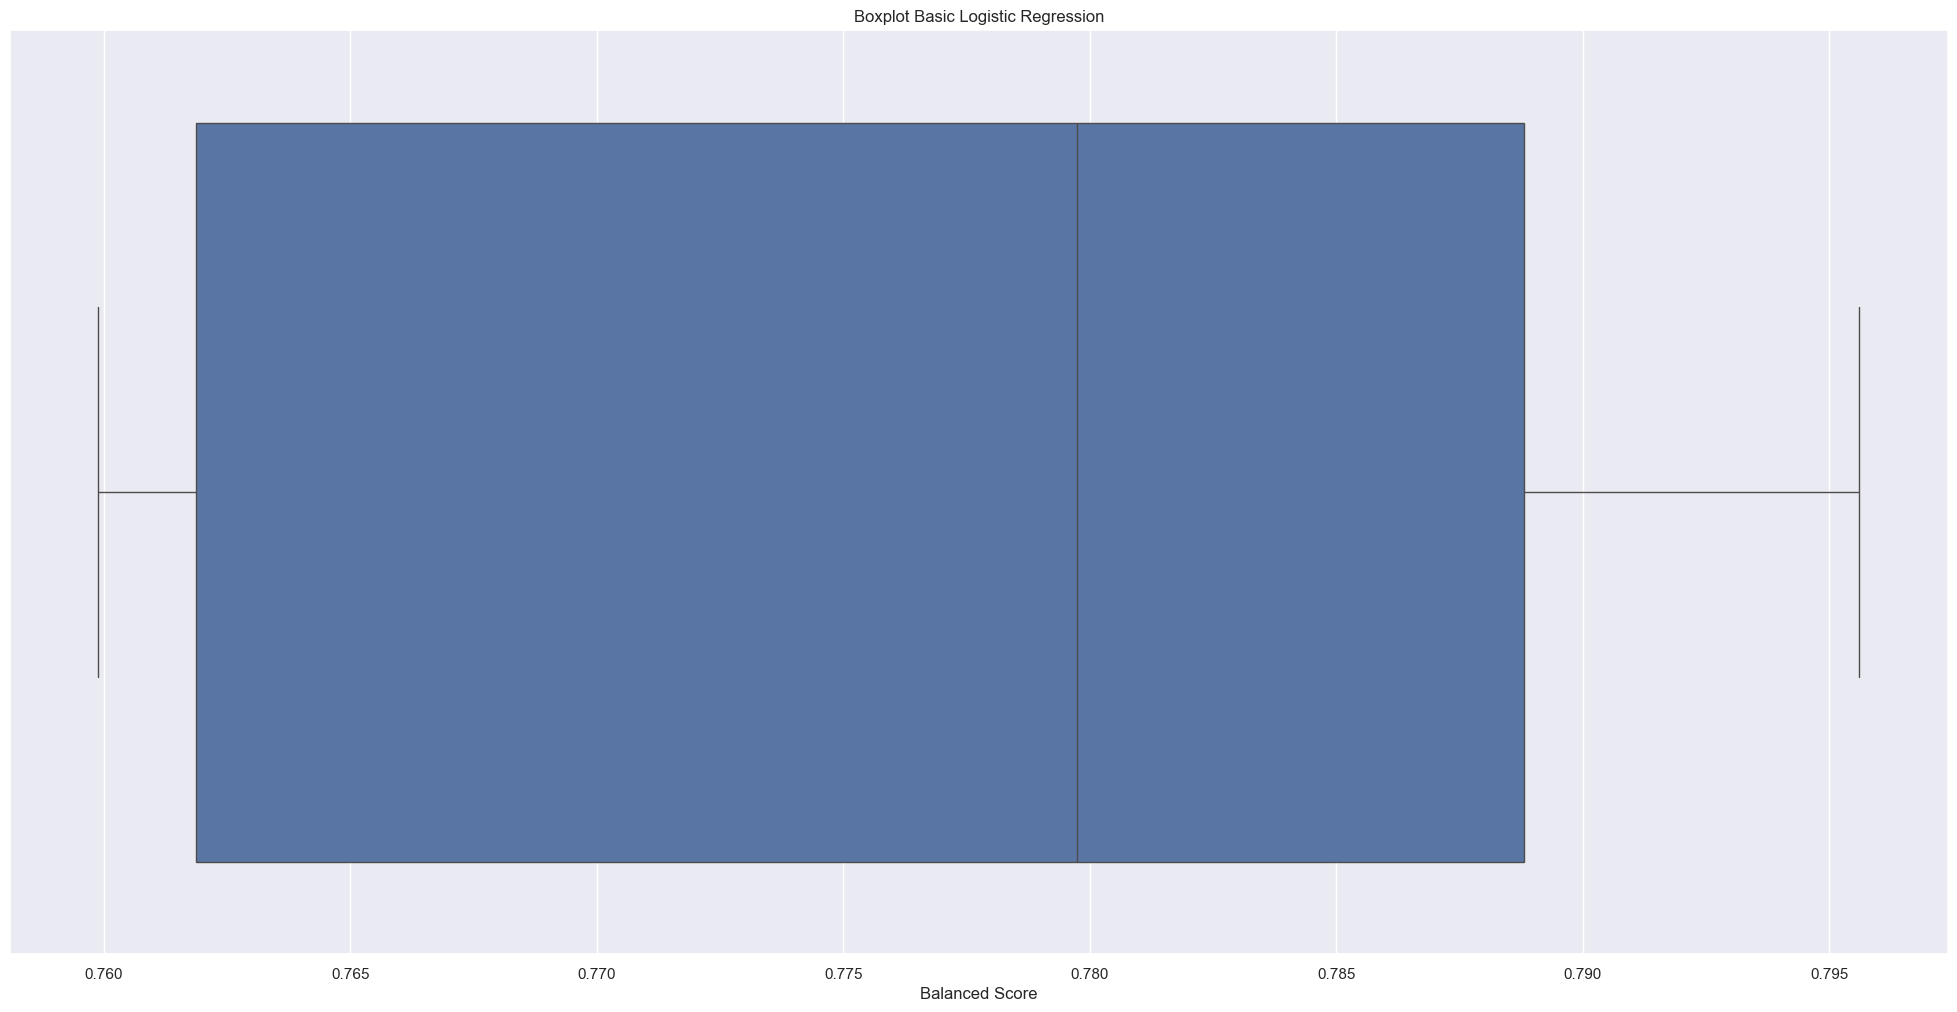

In [85]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_logistic['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [86]:
lr_tunned = TunedThresholdClassifierCV(lr, scoring="balanced_accuracy").fit(X_train, y_train)

In [87]:
print(f"Cut-off point found at {lr_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [88]:
y_hat_test_logistic = y_hat_test_logistic[:,1]
th = 0.010
yhat_tunned_lr = [1 if i > th else 0 for i in y_hat_test_logistic]

In [89]:
mt.balanced_accuracy_score(y_train_val,yhat_tunned_lr)

np.float64(0.9724617516238853)

In [90]:
mt.confusion_matrix(y_train_val, yhat_tunned_lr)

array([[661192,  10316],
       [    50,   1209]])

In [91]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [92]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [93]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

In [94]:
df_resultados = pd.DataFrame({
    'Modelo': ['RandomForest'] * len(scores['test_score']) + ['LogisticRegression'] * len(scores_logistic['test_score']),
    'Test Score': list(scores['test_score']) + list(scores_logistic['test_score'])
})

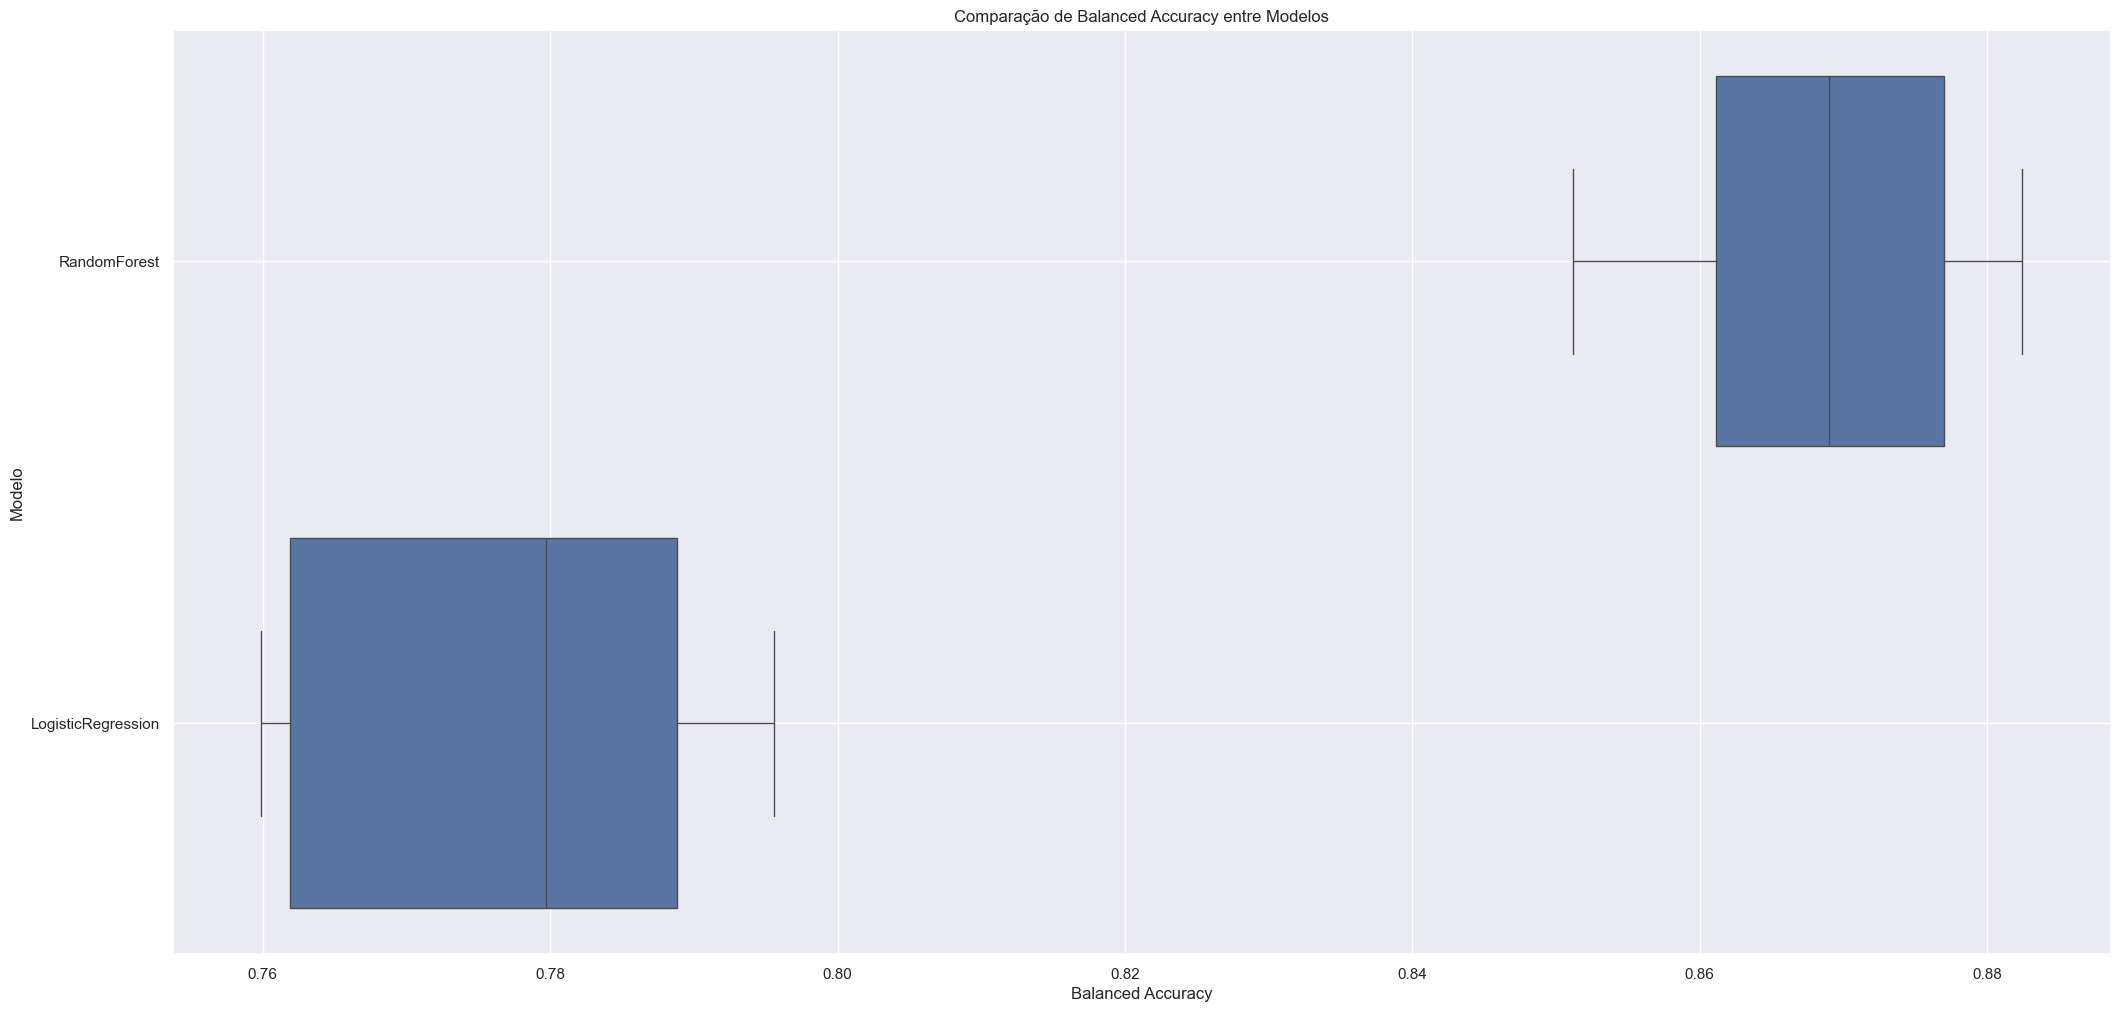

In [104]:
sns.boxplot(x='Test Score', y='Modelo', data=df_resultados)
plt.title('Comparação de Balanced Accuracy entre Modelos')
plt.xlabel('Balanced Accuracy')
plt.grid(True)
plt.show()

## 7.3 XGBoost

In [ ]:
# definition

xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=15, learning_rate=1, objective='binary:logistic')


xgb_model.fit(X_train, y_train)

# performace

y_hat_test_xgb= xgb_model.predict_proba(X_train_val)



In [ ]:
y_hat_test_xgb = y_hat_test_xgb[:,1]
th = 0.010
yhat_tunned_xgb = [1 if i > th else 0 for i in y_hat_test_xgb]

In [90]:
acc = mt.accuracy_score(y_train_val, yhat_tunned_xgb)
precision = mt.precision_score(y_train_val, yhat_tunned_xgb)
recall = mt.recall_score(y_train_val, yhat_tunned_xgb)
f1_score = mt.f1_score(y_train_val, yhat_tunned_xgb)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9964802078579954
Precision: 0.18187033849684453
Recall: 0.25178713264495634
F1-Score: 0.2111925383077948


In [91]:
mt.balanced_accuracy_score(y_train_val,yhat_tunned_xgb)

np.float64(0.6248317770362746)

In [92]:
mt.confusion_matrix(y_train_val, yhat_tunned_xgb)

array([[670082,   1426],
       [   942,    317]])

## 7.4 CATBoost

In [98]:
# definition

cat_model = cat.CatBoostClassifier(max_depth=15, learning_rate=1)


cat_model.fit(X_train, y_train)

# performace

y_hat_test_xgb= cat_model.predict_proba(X_train_val)

0:	learn: 0.0053222	total: 2.43s	remaining: 40m 25s
1:	learn: 0.0032001	total: 4.2s	remaining: 34m 54s
2:	learn: 0.0023481	total: 6.23s	remaining: 34m 31s
3:	learn: 0.0019954	total: 8.38s	remaining: 34m 47s
4:	learn: 0.0017876	total: 10.5s	remaining: 34m 48s
5:	learn: 0.0015964	total: 12.6s	remaining: 34m 40s
6:	learn: 0.0015686	total: 14.5s	remaining: 34m 11s
7:	learn: 0.0014629	total: 16.5s	remaining: 34m
8:	learn: 0.0013522	total: 18.4s	remaining: 33m 43s
9:	learn: 0.0012758	total: 20.4s	remaining: 33m 35s
10:	learn: 0.0012203	total: 22.4s	remaining: 33m 30s
11:	learn: 0.0011904	total: 24.2s	remaining: 33m 13s
12:	learn: 0.0011479	total: 26s	remaining: 32m 51s
13:	learn: 0.0011010	total: 27.8s	remaining: 32m 35s
14:	learn: 0.0010794	total: 29.8s	remaining: 32m 39s
15:	learn: 0.0010384	total: 31.7s	remaining: 32m 31s
16:	learn: 0.0010016	total: 33.7s	remaining: 32m 31s
17:	learn: 0.0009567	total: 35.7s	remaining: 32m 30s
18:	learn: 0.0009237	total: 37.7s	remaining: 32m 26s
19:	learn:

In [100]:
y_hat_test_cat = y_hat_test_xgb

In [101]:
y_hat_test_cat = y_hat_test_cat[:,1]
th = 0.010
yhat_tunned_cat = [1 if i > th else 0 for i in y_hat_test_cat]

In [103]:
acc = mt.accuracy_score(y_train_val, yhat_tunned_cat)
precision = mt.precision_score(y_train_val, yhat_tunned_cat)
recall = mt.recall_score(y_train_val, yhat_tunned_cat)
f1_score = mt.f1_score(y_train_val, yhat_tunned_cat)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9991245111606247
Precision: 0.7005988023952096
Recall: 0.9293089753772835
F1-Score: 0.798907476954592


In [105]:
scores_cat = cross_validate(cat_model, X_train_val, y_train_val, scoring='balanced_accuracy')

0:	learn: 0.0056563	total: 1.55s	remaining: 25m 52s
1:	learn: 0.0028564	total: 1.83s	remaining: 15m 15s
2:	learn: 0.0023724	total: 3.24s	remaining: 17m 56s
3:	learn: 0.0021256	total: 4.73s	remaining: 19m 37s
4:	learn: 0.0017552	total: 6.29s	remaining: 20m 51s
5:	learn: 0.0016651	total: 7.74s	remaining: 21m 22s
6:	learn: 0.0015316	total: 9.37s	remaining: 22m 9s
7:	learn: 0.0013964	total: 11s	remaining: 22m 47s
8:	learn: 0.0012442	total: 12.7s	remaining: 23m 16s
9:	learn: 0.0011315	total: 14.4s	remaining: 23m 42s
10:	learn: 0.0010531	total: 16.1s	remaining: 24m 11s
11:	learn: 0.0009939	total: 18s	remaining: 24m 41s
12:	learn: 0.0008818	total: 19.7s	remaining: 24m 58s
13:	learn: 0.0007937	total: 21.4s	remaining: 25m 4s
14:	learn: 0.0007071	total: 23s	remaining: 25m 8s
15:	learn: 0.0006844	total: 24.7s	remaining: 25m 16s
16:	learn: 0.0006626	total: 26.6s	remaining: 25m 38s
17:	learn: 0.0006502	total: 28.3s	remaining: 25m 42s
18:	learn: 0.0006396	total: 28.5s	remaining: 24m 30s
19:	learn: 0

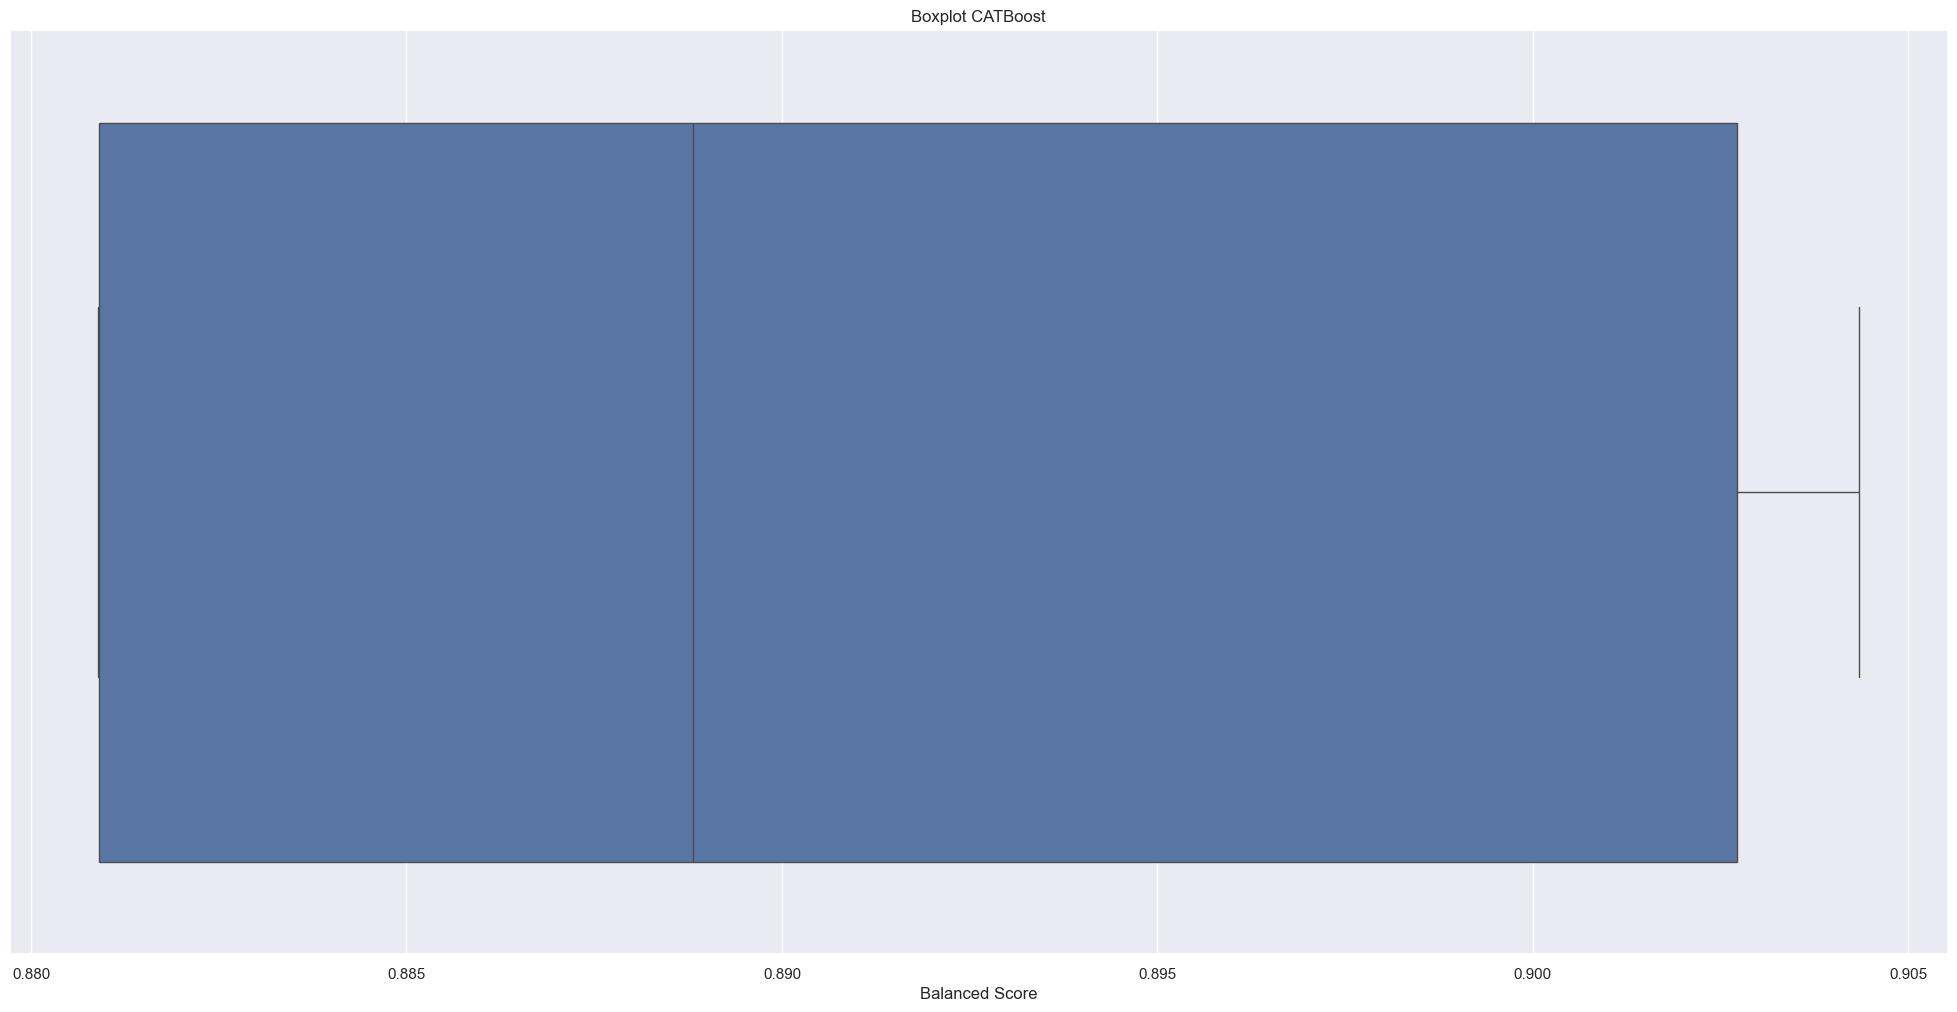

In [106]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_cat['test_score'])
plt.title('Boxplot CATBoost')
plt.xlabel('Balanced Score')
plt.show()

In [107]:
scores_cat

{'fit_time': array([1046.31996727,  847.99906158,  976.03784776,  807.81021619,
         406.75072646]),
 'score_time': array([0.62802172, 0.5034337 , 0.6230514 , 0.6702559 , 0.26580977]),
 'test_score': array([0.88881815, 0.88090026, 0.90434896, 0.90271821, 0.88089281])}

# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model